In [ ]:
# Scenario-Based Question
# A university wants to build a predictive model to estimate
#  student grades based on four factors:
# - Study hours per week
# - Attendance percentage
# - Previous exam score
# - Average sleep hours
# They collect data from 200 students and decide to use Ridge
#  Regression for prediction. To evaluate the model, they apply different cross-validation strategies:
# - Basic K-Fold CV (5 folds, shuffled) to check the stability of the model’s R² scores.
# - Multi-metric evaluation using both R² and Mean Squared Error (MSE), comparing training and validation
# scores.
# - Stratified K-Fold CV (for a separate classification task predicting pass/fail using Logistic Regression).

from sklearn.model_selection import KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

#Create a Synthetic dataset
X,y=make_regression(n_samples=1000,n_features=5,noise=15,random_state=42)

#Step2:Define Model
model=LinearRegression()

#Step 3:Define 5-fold
kf=KFold(n_splits=5,shuffle=True,random_state=42)

#Step 4: Evaluate model using R^2
scores=cross_val_score(model,X,y,cv=kf,scoring='r2')

#Step 5:print result
print("R^2 Score for eah fold:",scores.round(3))
print("Mean r^2:",scores.mean().round(3))
print("Std Dev:",scores.std().round(3))

#Step 6:interpret Result--
if scores.std()<0.05:
    print("Model is stable across folds")
else:
    print("Model performance varies across folds,investigate further")

R^2 Score for eah fold: [0.937 0.945 0.945 0.947 0.947]
Mean r^2: 0.944
Std Dev: 0.004
Model is stable across folds


In [ ]:
# Scenario: Predicting Patient Recovery Time
# A hospital research team wants to build a model to predict patient recovery time (in days) after
#  surgery based on several factors such as:
# - Age of the patient
# - Number of hours of post-surgery physiotherapy per week
# - Pre-existing health conditions (numeric severity score)
# - Length of hospital stay (days)
# - Average sleep hours during recovery
# They collect data from 1,000 patients and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

from sklearn.model_selection import KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

X,y=make_regression(n_samples=1000,n_features=5,noise=15,random_state=42)

model=LinearRegression()

kf=KFold(n_splits=5,shuffle=True,random_state=42)

#Step 4: Evaluate model using R^2
scores=cross_val_score(model,X,y,cv=kf,scoring='r2')

#Step 5:print result
print("R^2 Score for eah fold:",scores.round(3))
print("Mean r^2:",scores.mean().round(3))
print("Std Dev:",scores.std().round(3))

#Step 6:interpret Result--
if scores.std()<0.05:
    print("Model is stable across folds")
else:
    print("Model performance varies across folds,investigate further")

R^2 Score for eah fold: [0.937 0.945 0.945 0.947 0.947]
Mean r^2: 0.944
Std Dev: 0.004
Model is stable across folds


In [ ]:
# Scenario: Predicting Student Exam Performance
# A university research team wants to build a model to predict student exam scores (out of 100) based on several factors such as:
# - Number of study hours per week
# - Attendance percentage in lectures
# - Prior GPA (Grade Point Average)
# - Participation in group projects (numeric engagement score)
# - Average sleep hours during exam preparation
# They collect data from 800 students across different departments and decide to use Linear Regression.
# To evaluate the model, they apply 5-Fold Cross-Validation with R² as the performance metric.

from sklearn.model_selection import KFold,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

X,y=make_regression(n_samples=800,n_features=5,noise=15,random_state=42)
print(y.shape)

model=LinearRegression()

kf=KFold(n_splits=5,shuffle=True,random_state=42)

scores=cross_val_score(model,X,y,cv=kf,scoring='r2')

#Step 5:print result
print("R^2 Score for eah fold:",scores.round(3))
print("Mean r^2:",scores.mean().round(3))
print("Std Dev:",scores.std().round(3))

if scores.std()<0.05:
    print("Model is stable across folds")
else:
    print("Model performance varies across folds,investigate further")

(800,)
R^2 Score for eah fold: [0.987 0.988 0.989 0.988 0.988]
Mean r^2: 0.988
Std Dev: 0.001
Model is stable across folds


In [ ]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

X=np.linspace(0,6,30).reshape(-1,1)
y=(10*np.sin(X).ravel()+np.random.normal(scale=3,size=30))

#Define models
linear_model=make_pipeline(PolynomialFeatures(1),LinearRegression())
poly_model=make_pipeline(PolynomialFeatures(10),LinearRegression())
balanced_model=make_pipeline(PolynomialFeatures(3),LinearRegression())

#Fit model
linear_model.fit(X,y)
poly_model.fit(X,y)
balanced_model.fit(X,y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('linearregression', LinearRegression())])

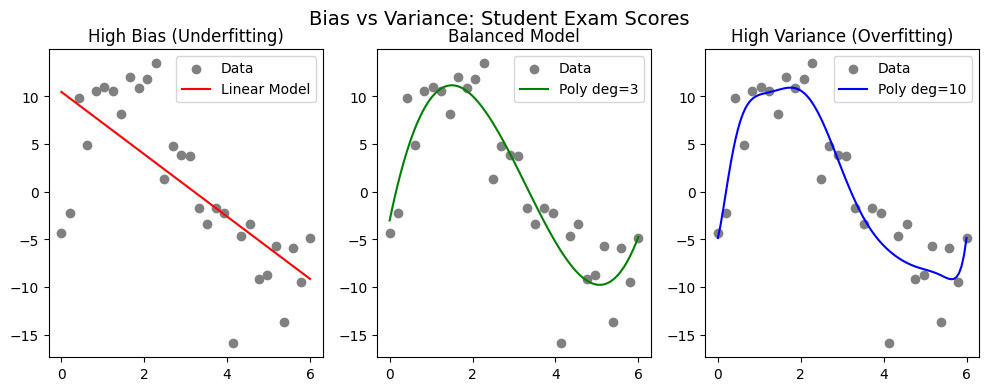

In [ ]:
#Prediction Continuing same question
X_test=np.linspace(0,6,100).reshape(-1,1)
y_linear=linear_model.predict(X_test)
y_poly=poly_model.predict(X_test)
y_balanced=balanced_model.predict(X_test)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

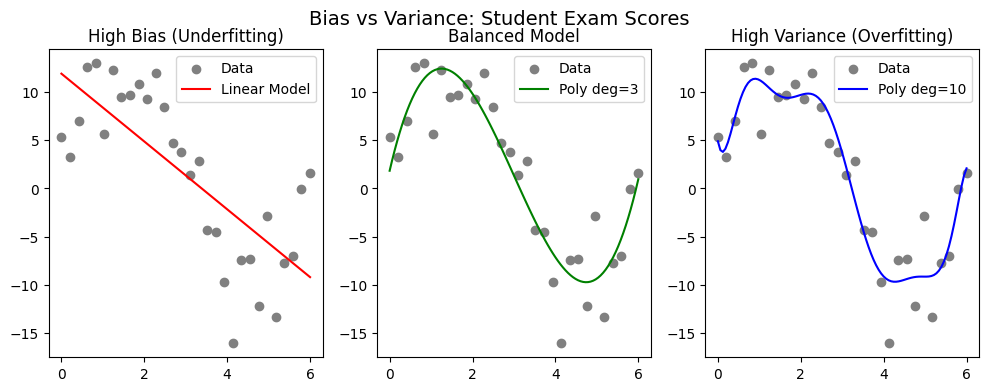

In [ ]:
# Scenario: Predicting Student Exam Scores
# A school wants to build a model to predict student exam scores based on study hours. They collect data
# from 30 students, but the scores are noisy because of other factors (like sleep, stress, or health).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes scores increase perfectly with study hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts too low or too high compared to actual scores,
# what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new students, what does this show about variance?
# - Part C: Which model is likely to generalize better to new students, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance” to
#  a teacher who doesn’t know machine learning?

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# --- Step 1: Simulate dataset ---
# 30 students, study hours vs exam scores (with noise)
np.random.seed(0)
X = np.linspace(0, 6, 30).reshape(-1, 1)   # study hours
y = (10 * np.sin(X)).ravel() + np.random.normal(scale=3, size=30)  # exam scores with noise

# --- Step 2: Define models ---
linear_model = make_pipeline(PolynomialFeatures(1), LinearRegression())   # simple line
poly_model   = make_pipeline(PolynomialFeatures(10), LinearRegression())  # complex curve
balanced_model = make_pipeline(PolynomialFeatures(3), LinearRegression()) # "just right"

# --- Step 3: Fit models ---
linear_model.fit(X, y)
poly_model.fit(X, y)
balanced_model.fit(X, y)

# --- Step 4: Predictions ---
X_test = np.linspace(0, 6, 100).reshape(-1, 1)
y_linear   = linear_model.predict(X_test)
y_poly     = poly_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)

# --- Step 5: Plot results ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear Model")
plt.title("High Bias (Underfitting)")
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Poly deg=3")
plt.title("Balanced Model")
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Poly deg=10")
plt.title("High Variance (Overfitting)")
plt.legend()

plt.suptitle("Bias vs Variance: Student Exam Scores", fontsize=14)
plt.show()

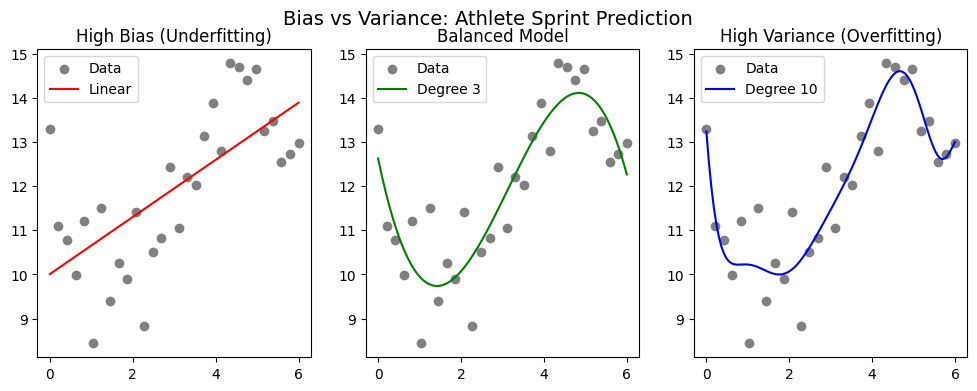

In [ ]:
# Scenario: Predicting Athlete Performance
# A sports academy wants to build a model to predict athlete sprint times (in seconds) based on training
#  hours. They collect data from 30 athletes, but the sprint times are noisy because of other factors (like diet, fatigue, or weather).
# They try two different models:
# - Linear Model (straight line) → very simple, assumes sprint times improve perfectly with more
#  training hours.
# - Polynomial Model (degree 10 curve) → very complex, tries to follow every bump in the data.

# Questions
# - Part A: If the linear model consistently predicts sprint times that are too fast or too slow compared
#  to actual results, what does this show about bias?
# - Part B: If the polynomial model fits the training data almost perfectly but gives very different
# predictions when tested on new athletes, what does this show about variance?
# - Part C: Which model is likely to generalize better to new athletes, and why?
# - Part D (Applied): How would you explain the difference between “high bias” and “high variance”
#  to a coach who doesn’t know machine learning?


# Scenario: Predicting Athlete Performance
# A sports academy wants to predict sprint time based on training hours

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


# ===============================
# Part A, B, C, D Answers (in comments)
# ===============================

# Part A:
# If linear model predicts too fast or too slow → High Bias (Underfitting)

# Part B:
# If polynomial degree 10 fits training perfectly but fails on new data
# → High Variance (Overfitting)

# Part C:
# Best model = Balanced model (degree 3)
# → Good generalization
# → Avoids high bias and high variance

# Part D:
# High Bias = model too simple
# High Variance = model too complex
# Balanced = best prediction for new athletes


# ===============================
# Step 1: Simulate dataset
# ===============================

np.random.seed(1)

# training hours (0 to 6 hours)
X = np.linspace(0, 6, 30).reshape(-1, 1)

# sprint time (seconds) with noise
y = (12 - 2*np.sin(X)).ravel() + np.random.normal(scale=0.8, size=30)


# ===============================
# Step 2: Define models
# ===============================

# Linear → High Bias
linear_model = make_pipeline(
    PolynomialFeatures(1),
    LinearRegression()
)

# Balanced → Good model
balanced_model = make_pipeline(
    PolynomialFeatures(3),
    LinearRegression()
)

# Complex → High Variance
poly_model = make_pipeline(
    PolynomialFeatures(10),
    LinearRegression()
)


# ===============================
# Step 3: Fit models
# ===============================

linear_model.fit(X, y)
balanced_model.fit(X, y)
poly_model.fit(X, y)


# ===============================
# Step 4: Predictions
# ===============================

X_test = np.linspace(0, 6, 100).reshape(-1, 1)

y_linear = linear_model.predict(X_test)
y_balanced = balanced_model.predict(X_test)
y_poly = poly_model.predict(X_test)


# ===============================
# Step 5: Plot results
# ===============================

plt.figure(figsize=(12, 4))


# ----- High Bias -----
plt.subplot(1, 3, 1)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_linear, color="red", label="Linear")
plt.title("High Bias (Underfitting)")
plt.legend()


# ----- Balanced -----
plt.subplot(1, 3, 2)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_balanced, color="green", label="Degree 3")
plt.title("Balanced Model")
plt.legend()


# ----- High Variance -----
plt.subplot(1, 3, 3)
plt.scatter(X, y, color="gray", label="Data")
plt.plot(X_test, y_poly, color="blue", label="Degree 10")
plt.title("High Variance (Overfitting)")
plt.legend()


plt.suptitle("Bias vs Variance: Athlete Sprint Prediction", fontsize=14)

plt.show()

In [ ]:
# Scenario: Package Delivery System
# A logistics company wants to build a machine learning model to optimize package delivery.
# They collect data about each package, including:
# - Size: Small, Medium, Large
# - Priority: Low, Medium, High
# Since machine learning models work with numbers (not text labels), the company decides to use Label
#  Encoding to convert these categories into numeric values.
# They apply Scikit-learn’s LabelEncoder to both features:
# - Size → converted into numeric codes (e.g., Small = 2, Medium = 1, Large = 0)
# - Priority → converted into numeric codes (e.g., Low = 1, Medium = 2, High = 0)
# They also check the mapping and decode the numbers back to the original labels to ensure correctness.

# Questions for Learners
# Part A: Why does the company need to convert categorical values like Small, Medium, Large into numbers
# before training a model?
# Part B: If the encoded values are 0, 1, 2, does the order (e.g., Large = 0, Medium = 1, Small = 2)
# matter for all models? Why or why not?
# Part C: How can the company decode the numeric values back into the original labels after prediction?
# Part D (Applied): Suppose the company adds a new category “Extra Large.” How would LabelEncoder handle
# this, and what challenge might arise if the model was already trained?


import pandas as pd
from sklearn.preprocessing import LabelEncoder


# ===============================
# Part A
# ===============================
# Why convert text to numbers?

# Machine learning models work with numbers only.
# Labels like Small, Medium, Large are text,
# so they must be converted to numeric values.

# Answer:
# Models require numeric input, so categorical values
# must be encoded into numbers.


# ===============================
# Part B
# ===============================
# Does order 0,1,2 matter?

# Yes for some models, No for others.

# Models like Linear Regression, SVM, KNN
# may think 2 > 1 > 0 meaning order matters.

# Tree models (Decision Tree, Random Forest)
# do not care about order.

# Answer:
# Order matters for some models because numbers imply ranking.


# ===============================
# Part C
# ===============================
# How to decode numbers back to labels?

# Use inverse_transform() in LabelEncoder

# This converts numbers → original text

# Answer:
# Use inverse_transform to get original labels.


# ===============================
# Part D
# ===============================
# What if new category "Extra Large" appears?

# LabelEncoder only knows categories used in training.
# New category will cause error.

# Problem:
# Model was trained without "Extra Large"

# Challenge:
# Need to retrain encoder + model.

# Answer:
# New category cannot be encoded unless encoder is fitted again.


# ===============================
# Step 1: Data
# ===============================

data = pd.DataFrame({
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small'],
    'Priority': ['Low', 'High', 'Medium', 'Low', 'High']
})

print("Original Data")
print(data)


# ===============================
# Step 2: Label Encoding
# ===============================

size_encoder = LabelEncoder()
priority_encoder = LabelEncoder()

data['Size_encoded'] = size_encoder.fit_transform(data['Size'])
data['Priority_encoded'] = priority_encoder.fit_transform(data['Priority'])

print("\nEncoded Data")
print(data)


# ===============================
# Step 3: Check mapping
# ===============================

print("\nSize mapping:", list(size_encoder.classes_))
print("Priority mapping:", list(priority_encoder.classes_))


# ===============================
# Step 4: Decode back
# ===============================

decoded_size = size_encoder.inverse_transform(data['Size_encoded'])
decoded_priority = priority_encoder.inverse_transform(data['Priority_encoded'])

print("\nDecoded Size:", decoded_size)
print("Decoded Priority:", decoded_priority)


# ===============================
# Step 5: New category test
# ===============================

try:
    new_value = size_encoder.transform(['Extra Large'])
    print(new_value)

except:
    print("\nError: New category not seen during training")

Original Data
     Size Priority
0   Small      Low
1  Medium     High
2   Large   Medium
3  Medium      Low
4   Small     High

Encoded Data
     Size Priority  Size_encoded  Priority_encoded
0   Small      Low             2                 1
1  Medium     High             1                 0
2   Large   Medium             0                 2
3  Medium      Low             1                 1
4   Small     High             2                 0

Size mapping: ['Large', 'Medium', 'Small']
Priority mapping: ['High', 'Low', 'Medium']

Decoded Size: ['Small' 'Medium' 'Large' 'Medium' 'Small']
Decoded Priority: ['Low' 'High' 'Medium' 'Low' 'High']

Error: New category not seen during training


In [ ]:
# Scenario: Restaurant Ordering System
# A restaurant wants to build a machine learning model to predict order preparation time.
# They collect data about each order, including:
# - Meal Type: Breakfast, Lunch, Dinner
# - Spice Level: Mild, Medium, Hot
# Since models can’t directly work with text labels, the restaurant uses Label Encoding to
# convert these categories into numbers.


import pandas as pd
from sklearn.preprocessing import LabelEncoder


# ===============================
# Part A
# ===============================
# Why convert text to numbers?

# Machine learning models cannot understand text.
# They require numeric input.
# So Breakfast, Lunch, Dinner must be converted to numbers.

# Answer:
# Categorical values must be encoded because ML models work with numbers.


# ===============================
# Part B
# ===============================
# Does order of numbers matter?

# LabelEncoder gives numbers like 0,1,2
# Some models think 2 > 1 > 0 meaning order exists.

# Linear / Distance based models → order matters
# Tree models → order does not matter

# Answer:
# Order may affect some models because numbers imply ranking.


# ===============================
# Part C
# ===============================
# How to convert numbers back to text?

# Use inverse_transform()

# Answer:
# LabelEncoder.inverse_transform() converts numbers back to labels.


# ===============================
# Part D
# ===============================
# What if new category appears (example: Brunch)?

# LabelEncoder only knows trained categories.
# New label will cause error.

# Need to fit encoder again.

# Answer:
# New category requires re-fitting encoder and retraining model.


# ===============================
# Step 1: Data
# ===============================

data = pd.DataFrame({
    'MealType': ['Breakfast', 'Lunch', 'Dinner', 'Lunch', 'Breakfast'],
    'SpiceLevel': ['Mild', 'Hot', 'Medium', 'Mild', 'Hot']
})

print("Original Data")
print(data)


# ===============================
# Step 2: Label Encoding
# ===============================

meal_encoder = LabelEncoder()
spice_encoder = LabelEncoder()

data['Meal_encoded'] = meal_encoder.fit_transform(data['MealType'])
data['Spice_encoded'] = spice_encoder.fit_transform(data['SpiceLevel'])

print("\nEncoded Data")
print(data)


# ===============================
# Step 3: Mapping check
# ===============================

print("\nMeal mapping:", list(meal_encoder.classes_))
print("Spice mapping:", list(spice_encoder.classes_))


# ===============================
# Step 4: Decode back
# ===============================

decoded_meal = meal_encoder.inverse_transform(data['Meal_encoded'])
decoded_spice = spice_encoder.inverse_transform(data['Spice_encoded'])

print("\nDecoded Meal:", decoded_meal)
print("Decoded Spice:", decoded_spice)


# ===============================
# Step 5: New category test
# ===============================

try:
    meal_encoder.transform(['Brunch'])

except:
    print("\nError: New category not seen during training")

Original Data
    MealType SpiceLevel
0  Breakfast       Mild
1      Lunch        Hot
2     Dinner     Medium
3      Lunch       Mild
4  Breakfast        Hot

Encoded Data
    MealType SpiceLevel  Meal_encoded  Spice_encoded
0  Breakfast       Mild             0              2
1      Lunch        Hot             2              0
2     Dinner     Medium             1              1
3      Lunch       Mild             2              2
4  Breakfast        Hot             0              0

Meal mapping: ['Breakfast', 'Dinner', 'Lunch']
Spice mapping: ['Hot', 'Medium', 'Mild']

Decoded Meal: ['Breakfast' 'Lunch' 'Dinner' 'Lunch' 'Breakfast']
Decoded Spice: ['Mild' 'Hot' 'Medium' 'Mild' 'Hot']

Error: New category not seen during training


In [ ]:
# Scenario: Employee Training & Satisfaction Survey
# A company conducts a survey to understand how employee education level and job satisfaction affect performance.
# They collect data such as:
# - Education: High School, Bachelor, Master, PhD
# - Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., PhD is higher than Bachelor, Excellent is better
#  than Good), the company decides to use Ordinal Encoding to convert them into numbers that respect
#  this ranking.
# They define custom ordering:
# - Education → High School (0), Bachelor (1), Master (2), PhD (3)
# - Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.

# Questions for Learners
# Part A: Why is it important to use Ordinal Encoding instead of simple Label Encoding for ordered
# categories like education level?
# Part B: If the company encoded “PhD = 0” and “High School = 3,” what problem might arise in
# interpreting the model?
# Part C: How does Ordinal Encoding differ from One-Hot Encoding in representing categorical data?
# Part D (Applied): Suppose the company adds a new satisfaction level “Outstanding.” How should they
# update their encoding scheme to keep the order meaningful?


import pandas as pd
from sklearn.preprocessing import OrdinalEncoder


# ===============================
# Part A
# ===============================
# Why use Ordinal Encoding instead of Label Encoding?

# LabelEncoder gives random numbers (no order)
# But Education and Satisfaction have ranking

# High School < Bachelor < Master < PhD
# Poor < Average < Good < Excellent

# Ordinal Encoding keeps correct order

# Answer:
# Ordinal Encoding is needed when categories have natural ranking.


# ===============================
# Part B
# ===============================
# What if PhD = 0 and High School = 3 ?

# Model will think High School > PhD
# Which is wrong

# This can give wrong predictions

# Answer:
# Wrong ordering causes incorrect interpretation by model.


# ===============================
# Part C
# ===============================
# Difference between Ordinal and One-Hot Encoding

# Ordinal → single column with order
# Example: 0,1,2,3

# OneHot → multiple columns
# Example:
# HighSchool 0/1
# Bachelor   0/1
# Master     0/1
# PhD        0/1

# Ordinal keeps ranking
# OneHot removes ranking

# Answer:
# Ordinal keeps order, OneHot treats categories as independent.


# ===============================
# Part D
# ===============================
# New category: "Outstanding"

# Need to update order list

# Poor < Average < Good < Excellent < Outstanding

# Must refit encoder

# Answer:
# Add new level in correct order and refit encoder.


# ===============================
# Step 1: Data
# ===============================

data = pd.DataFrame({
    'Education': ['High School', 'Bachelor', 'Master', 'PhD', 'Bachelor'],
    'Satisfaction': ['Poor', 'Good', 'Excellent', 'Average', 'Good']
})

print("Original Data")
print(data)


# ===============================
# Step 2: Ordinal Encoding with order
# ===============================

education_order = ['High School', 'Bachelor', 'Master', 'PhD']
satisfaction_order = ['Poor', 'Average', 'Good', 'Excellent']

encoder = OrdinalEncoder(
    categories=[education_order, satisfaction_order]
)

data[['Edu_encoded', 'Sat_encoded']] = encoder.fit_transform(
    data[['Education', 'Satisfaction']]
)

print("\nEncoded Data")
print(data)


# ===============================
# Step 3: Manual mapping check
# ===============================

edu_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

sat_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
}

data['Edu_manual'] = data['Education'].map(edu_map)
data['Sat_manual'] = data['Satisfaction'].map(sat_map)

print("\nManual Mapping")
print(data[['Education','Edu_encoded','Edu_manual',
            'Satisfaction','Sat_encoded','Sat_manual']])


# ===============================
# Step 4: New category example
# ===============================

new_satisfaction_order = [
    'Poor',
    'Average',
    'Good',
    'Excellent',
    'Outstanding'
]

print("\nNew order should be:", new_satisfaction_order)

Original Data
     Education Satisfaction
0  High School         Poor
1     Bachelor         Good
2       Master    Excellent
3          PhD      Average
4     Bachelor         Good

Encoded Data
     Education Satisfaction  Edu_encoded  Sat_encoded
0  High School         Poor          0.0          0.0
1     Bachelor         Good          1.0          2.0
2       Master    Excellent          2.0          3.0
3          PhD      Average          3.0          1.0
4     Bachelor         Good          1.0          2.0

Manual Mapping
     Education  Edu_encoded  Edu_manual Satisfaction  Sat_encoded  Sat_manual
0  High School          0.0           0         Poor          0.0           0
1     Bachelor          1.0           1         Good          2.0           2
2       Master          2.0           2    Excellent          3.0           3
3          PhD          3.0           3      Average          1.0           1
4     Bachelor          1.0           1         Good          2.0         

In [ ]:
# Scenario: Patient Health Monitoring
# A hospital wants to analyze patient records to understand how disease severity and recovery
# satisfaction affect treatment outcomes.
# They collect data such as:
# - Disease Severity: Mild, Moderate, Severe, Critical
# - Recovery Satisfaction: Poor, Average, Good, Excellent
# Since these categories have a natural order (e.g., Critical is worse than Mild, Excellent is
# better than Poor), the hospital uses Ordinal Encoding to convert them into numbers that respect this
#  ranking.
# They define custom ordering:
# - Disease Severity → Mild (0), Moderate (1), Severe (2), Critical (3)
# - Recovery Satisfaction → Poor (0), Average (1), Good (2), Excellent (3)
# They also compare this with a manual dictionary mapping to ensure consistency.


import pandas as pd
from sklearn.preprocessing import OrdinalEncoder


# ===============================
# Part A
# ===============================
# Why use Ordinal Encoding instead of Label Encoding?

# Disease severity and satisfaction have ranking
# Mild < Moderate < Severe < Critical
# Poor < Average < Good < Excellent

# LabelEncoder may give wrong order
# OrdinalEncoder keeps correct order

# Answer:
# Ordinal Encoding is needed when categories have natural ranking.


# ===============================
# Part B
# ===============================
# What if encoding order is wrong?
# Example: Critical = 0 and Mild = 3

# Model will think Mild is worse than Critical
# This causes wrong interpretation

# Answer:
# Wrong order leads to incorrect model predictions.


# ===============================
# Part C
# ===============================
# Difference between Ordinal and OneHot Encoding

# Ordinal → single column with order (0,1,2,3)
# OneHot → multiple columns (no order)

# Ordinal keeps ranking
# OneHot removes ranking

# Answer:
# Ordinal keeps order, OneHot treats categories independently.


# ===============================
# Part D
# ===============================
# Suppose new level added: "Very Critical"

# Need to update order:
# Mild < Moderate < Severe < Critical < Very Critical

# Must refit encoder

# Answer:
# Add new category in correct order and fit encoder again.


# ===============================
# Step 1: Data
# ===============================

data = pd.DataFrame({
    'Severity': ['Mild', 'Moderate', 'Severe', 'Critical', 'Moderate'],
    'Satisfaction': ['Poor', 'Good', 'Excellent', 'Average', 'Good']
})

print("Original Data")
print(data)


# ===============================
# Step 2: Ordinal Encoding
# ===============================

severity_order = ['Mild', 'Moderate', 'Severe', 'Critical']
satisfaction_order = ['Poor', 'Average', 'Good', 'Excellent']

encoder = OrdinalEncoder(
    categories=[severity_order, satisfaction_order]
)

data[['Severity_encoded', 'Satisfaction_encoded']] = encoder.fit_transform(
    data[['Severity', 'Satisfaction']]
)

print("\nEncoded Data")
print(data)


# ===============================
# Step 3: Manual mapping check
# ===============================

severity_map = {
    'Mild': 0,
    'Moderate': 1,
    'Severe': 2,
    'Critical': 3
}

satisfaction_map = {
    'Poor': 0,
    'Average': 1,
    'Good': 2,
    'Excellent': 3
}

data['Severity_manual'] = data['Severity'].map(severity_map)
data['Satisfaction_manual'] = data['Satisfaction'].map(satisfaction_map)

print("\nManual Mapping Check")
print(data[['Severity','Severity_encoded','Severity_manual',
            'Satisfaction','Satisfaction_encoded','Satisfaction_manual']])


# ===============================
# Step 4: New category example
# ===============================

new_severity_order = [
    'Mild',
    'Moderate',
    'Severe',
    'Critical',
    'Very Critical'
]

print("\nUpdated order:", new_severity_order)

Original Data
   Severity Satisfaction
0      Mild         Poor
1  Moderate         Good
2    Severe    Excellent
3  Critical      Average
4  Moderate         Good

Encoded Data
   Severity Satisfaction  Severity_encoded  Satisfaction_encoded
0      Mild         Poor               0.0                   0.0
1  Moderate         Good               1.0                   2.0
2    Severe    Excellent               2.0                   3.0
3  Critical      Average               3.0                   1.0
4  Moderate         Good               1.0                   2.0

Manual Mapping Check
   Severity  Severity_encoded  Severity_manual Satisfaction  \
0      Mild               0.0                0         Poor   
1  Moderate               1.0                1         Good   
2    Severe               2.0                2    Excellent   
3  Critical               3.0                3      Average   
4  Moderate               1.0                1         Good   

   Satisfaction_encoded  Satisf

In [ ]:
# Scenario: Online Food Delivery App
# An online food delivery company wants to build a machine learning model to predict delivery time based
#  on the type of cuisine ordered.
# They collect data such as:
# - Cuisine Type: Italian, Chinese, Indian, Mexican
# Since machine learning models can’t directly work with text labels, the company decides to use One-Hot
#  Encoding.
# This method creates a new column for each cuisine type:
# - Italian → [1, 0, 0, 0]
# - Chinese → [0, 1, 0, 0]
# - Indian → [0, 0, 1, 0]
# - Mexican → [0, 0, 0, 1]
# They set sparse=False so the encoder returns a regular NumPy array instead of a sparse matrix, making
#  the results easier to read and print for analysis.

# Questions for Learners
# Part A: Why is One-Hot Encoding more appropriate than Label Encoding for categories like cuisine type?
# Part B: What does sparse=False do, and why might it be useful in this scenario?
# Part C: If the company adds a new cuisine type (e.g., “Thai”), how will One-Hot Encoding handle it?
# Part D (Applied): What potential problem could arise if the company has hundreds of cuisine types, and
#  how might they solve it?

import pandas as pd
from sklearn.preprocessing import OneHotEncoder


# ===============================
# Part A
# ===============================
# Why One-Hot instead of Label Encoding?

# Cuisine types have no order
# Italian is not greater than Chinese

# LabelEncoding would give numbers like 0,1,2,3
# Model may think 3 > 1 > 0 meaning order exists

# OneHotEncoding creates separate columns
# so no ranking problem

# Answer:
# OneHotEncoding is better for unordered categories.


# ===============================
# Part B
# ===============================
# What does sparse=False do?

# By default encoder returns sparse matrix
# sparse=False returns normal NumPy array

# Easier to print and read

# Answer:
# sparse=False gives normal array instead of sparse matrix.


# ===============================
# Part C
# ===============================
# What if new cuisine added (Thai)?

# Encoder only knows trained categories
# Need to fit again with new category

# Otherwise error occurs

# Answer:
# Must refit encoder when new category appears.


# ===============================
# Part D
# ===============================
# Problem with many categories?

# OneHot creates many columns
# Too many cuisines → too many columns

# Problem = High dimensional data

# Solution:
# Use Feature Hashing / Embedding / Grouping

# Answer:
# Large categories cause too many columns, can use hashing or grouping.


# ===============================
# Step 1: Data
# ===============================

data = pd.DataFrame({
    'Cuisine': ['Italian', 'Chinese', 'Indian', 'Mexican', 'Indian']
})

print("Original Data")
print(data)


# ===============================
# Step 2: One-Hot Encoding
# ===============================

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(data[['Cuisine']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Cuisine'])
)

print("\nEncoded Data")
print(encoded_df)


# ===============================
# Step 3: Combine with original
# ===============================

final_data = pd.concat([data, encoded_df], axis=1)

print("\nFinal Data")
print(final_data)


# ===============================
# Step 4: New category example
# ===============================

try:
    encoder.transform([['Thai']])
except:
    print("\nError: New category not seen during training")


# ===============================
# Step 5: Many categories problem
# ===============================

print("\nIf cuisines are too many → too many columns created")
print("Possible solution: Feature hashing / grouping / embeddings")

Original Data
   Cuisine
0  Italian
1  Chinese
2   Indian
3  Mexican
4   Indian

Encoded Data
   Cuisine_Chinese  Cuisine_Indian  Cuisine_Italian  Cuisine_Mexican
0              0.0             0.0              1.0              0.0
1              1.0             0.0              0.0              0.0
2              0.0             1.0              0.0              0.0
3              0.0             0.0              0.0              1.0
4              0.0             1.0              0.0              0.0

Final Data
   Cuisine  Cuisine_Chinese  Cuisine_Indian  Cuisine_Italian  Cuisine_Mexican
0  Italian              0.0             0.0              1.0              0.0
1  Chinese              1.0             0.0              0.0              0.0
2   Indian              0.0             1.0              0.0              0.0
3  Mexican              0.0             0.0              0.0              1.0
4   Indian              0.0             1.0              0.0              0.0

Error: New 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
